# Archetypal Analysis

## Introduction

In this vignette, we present

1) a brief overview of the theory behind archetypal analysis
2) a description of the optimization procedure used in our implementation
3) a guide to using the `AA` class and its `AA.fit()` method

First, we will import some package that we need throughout this vignette.

In [1]:
from datetime import datetime
import partipy as pt
import numpy as np
import matplotlib.pyplot as plt

Now, we simulate a dataset to provide an intuitive explanation of archetypal analysis. To make the simulation more realistic, we add noise to each data point by sampling a noise vector from an isotropic Gaussian distribution.

In [2]:
X, A, Z = pt.simulate_archetypes(n_samples=1_000, n_archetypes=3, n_dimensions=2, 
                                 noise_std=0.10, seed=123)
print(f"{X.shape}")
print(f"{A.shape}")
print(f"{Z.shape}")

(1000, 2)
(1000, 3)
(3, 2)


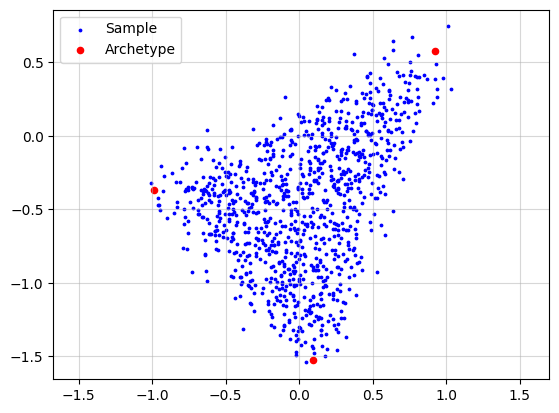

In [3]:
plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.legend()
plt.axis("equal")
plt.show()

## Standard Archetypal Analysis

To recover the archetypes we simply need to call

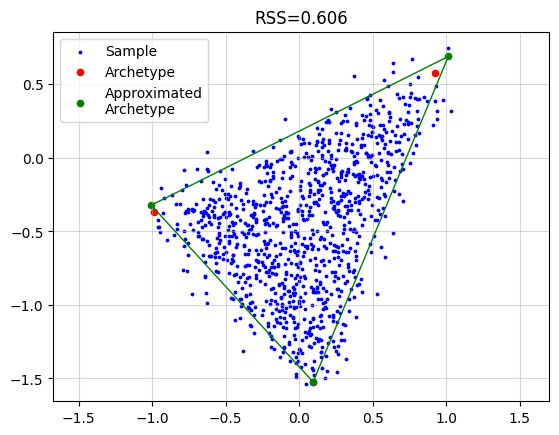

In [4]:
AA_object = pt.AA(n_archetypes=3)
AA_object.fit(X)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

## Relaxation of Convex Constraint on Archetypes

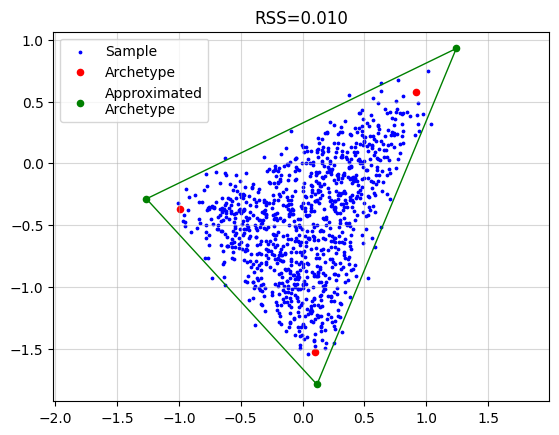

In [5]:
AA_object = pt.AA(n_archetypes=3, delta=0.25)
AA_object.fit(X)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

## Robust Archetypal Analysis

To demonstrate robust archetypal anaysis we will add some outliers here.

In [6]:
n_outliers = 5
outlier_mean = np.array([-1.0, 1.5])
X_wo = np.zeros((X.shape[0]+n_outliers, X.shape[1]))
X_wo[:X.shape[0], :] = X.copy()
rng = np.random.default_rng(seed=42)
X_wo[X.shape[0]:, :] = rng.normal(loc=outlier_mean, scale=(0.1, 0.1), size=(n_outliers, 2))

print(f"{X_wo.shape}")
print(f"{A.shape}")
print(f"{Z.shape}")

(1005, 2)
(1000, 3)
(3, 2)


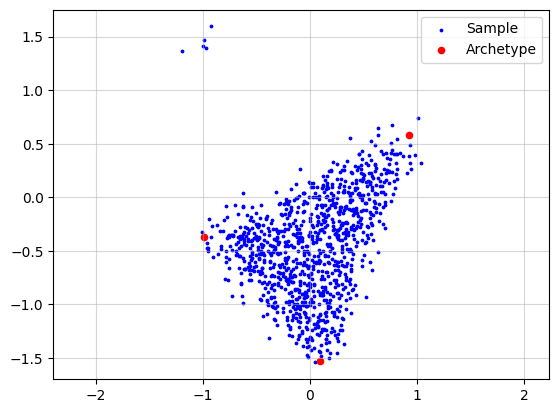

In [7]:
plt.grid(alpha=0.5)
plt.scatter(x=X_wo[:, 0], y=X_wo[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.legend()
plt.axis("equal")
plt.show()

Now if we just run the standard algorithm we obtain.

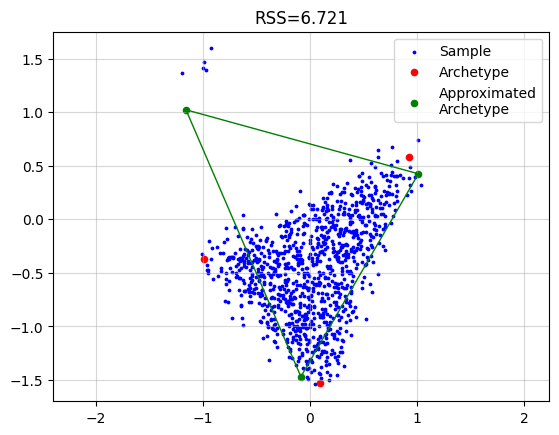

In [8]:
AA_object = pt.AA(n_archetypes=3)
AA_object.fit(X_wo)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X_wo[:, 0], y=X_wo[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

However, if we use the robust implementation we get a much better result. In the plot we colored each sample by the final weight. We see that the outlier samples have zero weight.

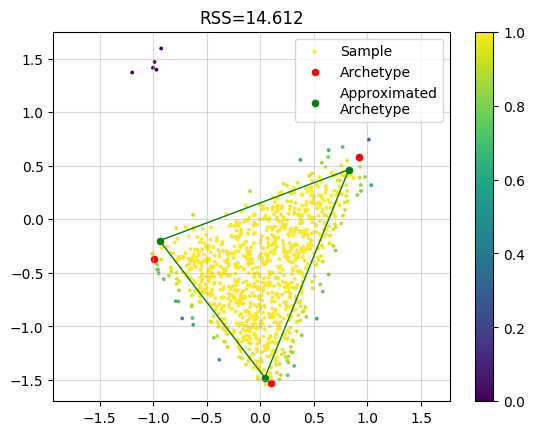

In [9]:
AA_object = pt.AA(n_archetypes=3, weight="bisquare", early_stopping=False)
AA_object.fit(X_wo)
Z_hat = AA_object.Z

plt.grid(alpha=0.5)
plt.scatter(x=X_wo[:, 0], y=X_wo[:, 1], s=3, c=AA_object.W, label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.colorbar()
plt.axis("equal")
plt.show()

## Coresets

Let's use the same archetypes but generate much more samples.

In [10]:
X, A, Z = pt.simulate_archetypes(n_samples=200_000, n_archetypes=3, n_dimensions=2, 
                                 noise_std=0.10, seed=123)
print(f"{X.shape}")
print(f"{A.shape}")
print(f"{Z.shape}")

(200000, 2)
(200000, 3)
(3, 2)


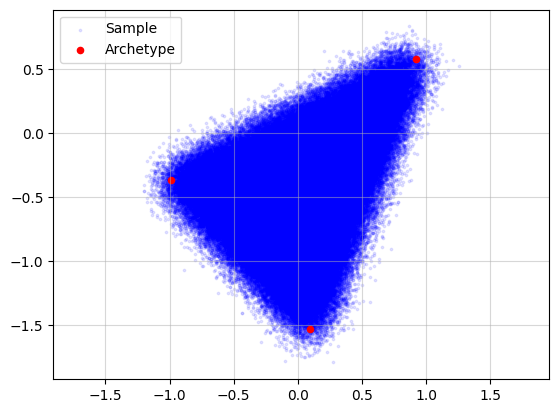

In [11]:
plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample", alpha=0.1)
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.legend()
plt.axis("equal")
plt.show()

Running archetypal analysis now takes quite some time

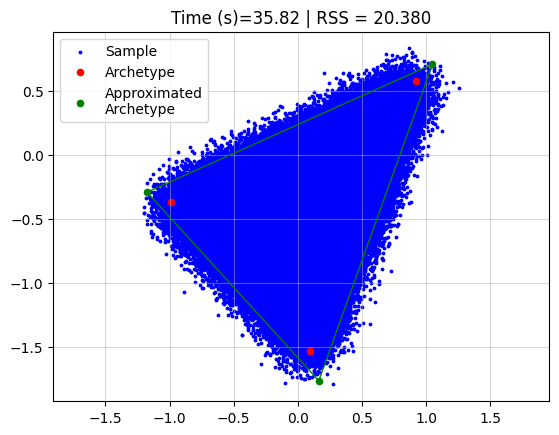

In [12]:
start = datetime.now()
AA_object = pt.AA(n_archetypes=3)
AA_object.fit(X)
Z_hat = AA_object.Z
end = datetime.now()
time = (end - start).total_seconds()

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"Time (s)={time:.2f} | RSS = {AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()

However, if we use coresets we can drastically reduce the time, without affecting the performance a lot.

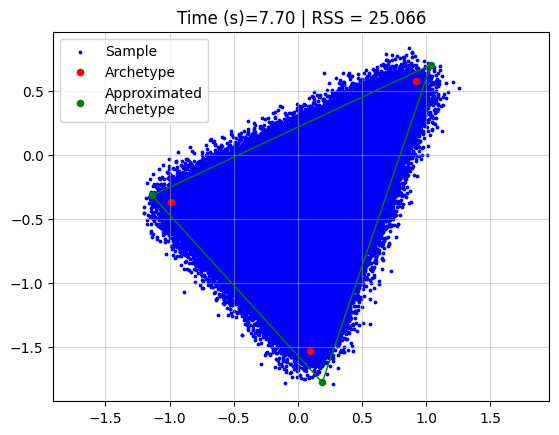

In [13]:
start = datetime.now()
AA_object = pt.AA(n_archetypes=3, coreset_algorithm="standard", coreset_fraction=0.05)
AA_object.fit(X)
Z_hat = AA_object.Z
end = datetime.now()
time = (end - start).total_seconds()

plt.grid(alpha=0.5)
plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=20, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=20, c="green", label="Approximated\nArchetype")
Z_loop = np.vstack([Z_hat, Z_hat[0]])
plt.plot(Z_loop[:, 0], Z_loop[:, 1], c="green", linestyle='-', linewidth=1)
plt.title(f"Time (s)={time:.2f} | RSS = {AA_object.RSS:.3f}")
plt.legend()
plt.axis("equal")
plt.show()